# EEG Reconstruction and Denoising using the ADMM 

In this notebook, we performed batch processing on all EEG EDF files in the dataset. It computes reconstruction and denoising results, saves plots as PNG, and compares performance across subjects and groups.


In [19]:
import pyedflib as ed
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct
import os
import pandas as pd
import glob
from scipy.linalg import inv

In [ ]:
# Function definitions 

def soft_threshold(z, lamb):
    return np.sign(z) * np.maximum(np.abs(z) - lamb, 0.0)

def admm(max_iteration, rho, lam, H, y, N):
    s = y.copy()
    z = np.zeros(N)
    u = np.zeros(N)
    K = inv(H.T @ H + rho * np.eye(N))
    Hy = H.T @ y
    for iteration in range(max_iteration):
        s = K @ (Hy + rho * (z - u))
        z = soft_threshold(s + u, lam / rho)
        u = u + (s - z)
    return s, z, u

def add_gaussian_noise(k, sigma=8e-6, alpha=0.5):
    g = np.random.normal(0, sigma, len(k))
    return k + alpha * g

def add_laplacian_noise(k, b=8e-6, beta=0.5):
    l = np.random.laplace(0, b, len(k))
    return k + beta * l

def add_gaussian_laplacian_noise(k, sigma=8e-6, b=8e-6, alpha=0.5, beta=0.5):
    g = np.random.normal(0, sigma, len(k))
    l = np.random.laplace(0, b, len(k))
    return k + alpha * g + beta * l

def denoise_mixed_admm_matrix_form(y, lam, gamma, rho=0.014, max_iter=350, tol=1e-6):
    n = len(y)
    D = np.eye(n) - np.eye(n, k=1)
    D = D[:-1, :]
    DT = D.T
    I = np.eye(n)
    M = I + rho * DT @ D
    M_inv = inv(M)
    x = y.copy()
    n_l = np.zeros_like(y)
    z = np.zeros(n - 1)
    u = np.zeros(n - 1)
    for k in range(max_iter):
        x_old = x.copy()
        rhs_x = y - n_l + rho * DT @ (z - u)
        x = M_inv @ rhs_x
        n_l = soft_threshold(y - x, gamma)
        Dx = D @ x
        z = soft_threshold(Dx + u, lam / rho)
        u = u + (Dx - z)
        rel_change = np.linalg.norm(x - x_old) / (np.linalg.norm(x_old) + 1e-9)
        if rel_change < tol:
            break
    return x

In [ ]:
# Dataset path - update this to the actual path
dataset_path = r"data"  # Replace with actual dataset folder path
root_path = r"root"
results_path = os.path.join(root_path, "results")
os.makedirs(results_path, exist_ok=True)

# create per-plot-type folders under root_path/results
recon_path = os.path.join(results_path, "Reconstruction")
denoise_path = os.path.join(results_path, "Denoised")
freq_path = os.path.join(results_path, "Frequency")
os.makedirs(recon_path, exist_ok=True)
os.makedirs(denoise_path, exist_ok=True)
os.makedirs(freq_path, exist_ok=True)

# Load subjects info
subjects_info_path = os.path.join(dataset_path, "subject-info.csv")
if os.path.exists(subjects_info_path):
    subjects_df = pd.read_csv(subjects_info_path)
    print("Subjects info loaded.")
else:
    print("subject-info.csv not found. Proceeding without group info.")
    subjects_df = None

# Get all EDF files
edf_files = glob.glob(os.path.join(dataset_path, "**", "*.edf"), recursive=True)
print(f"Found {len(edf_files)} EDF files.")

Subjects info loaded.
Found 72 EDF files.


In [ ]:
# Parameter decleration
N = 5000
M = int(0.1 * N)  # Reduced compression ratio to introduce more error
max_iteration = 200
rho = 0.5
lam = 0.1
rng = np.random.default_rng(0)
C = rng.normal(size=(M, N)) / np.sqrt(M)
phi = dct(np.eye(N), axis=0, norm='ortho', type=2)
H = C @ phi

# Results storage
results = []

for edf_path in edf_files:
    subject_name = os.path.basename(edf_path).replace('.edf', '')
    subject_id = subject_name.split('_')[0]
    task_type = subject_name.split('_')[1]  # 1 or 2
    
    # Get group if available
    group = 'Unknown'
    if subjects_df is not None:
        subj_row = subjects_df[subjects_df['Subject'] == subject_id]
        if not subj_row.empty:
            group = 'G' if subj_row['Count quality'].values[0] == 1 else 'B'
    
    try:
        # Load signal
        raw_signal = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        sample_frequency = raw_signal.info['sfreq']
        
        # Process first channel (or all, but for simplicity first)
        signal_length = raw_signal.get_data().shape[1]
        N_actual = min(N, signal_length)  # Adjust N to actual signal length
        x = raw_signal.get_data()[0, :N_actual]
        original_signal = x
        x_mean = np.mean(x)
        x_std = np.std(x)
        x_norm = (x - x_mean) / x_std
        
        # Adjust matrices for actual N
        if N_actual != N:
            C_actual = rng.normal(size=(M, N_actual)) / np.sqrt(M)
            phi_actual = dct(np.eye(N_actual), axis=0, norm='ortho', type=2)
            H_actual = C_actual @ phi_actual
        else:
            C_actual = C
            phi_actual = phi
            H_actual = H
        
        y_norm = C_actual @ x_norm
        
        # Reconstruction
        sparse_vector, _, _ = admm(max_iteration, rho, lam, H_actual, y_norm, N_actual)
        reconstructed_signal_norm = phi_actual @ sparse_vector
        reconstructed_signal = reconstructed_signal_norm * x_std + x_mean
        rmse_rec = np.sqrt(np.sum((x - reconstructed_signal)**2) / len(reconstructed_signal))
        
        # Plot reconstruction
        plt.figure(figsize=(12, 8))
        plt.plot(x, label="Original Signal", color="blue")
        plt.plot(reconstructed_signal, label="Reconstructed Signal", color="red")
        plt.legend()
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.title(f"Original vs Reconstructed EEG Signal - {subject_name}")
        plt.savefig(os.path.join(recon_path, f"{subject_name}_reconstruction.png"))
        plt.close()
        
        # Denoising with increased noise and parameters
        noised_signal = add_gaussian_laplacian_noise(x, sigma=1e-5, b=1e-5, alpha=1, beta=1)
        denoised_signal = denoise_mixed_admm_matrix_form(noised_signal, lam=0.01, gamma=0.5)
        rmse_den = np.sqrt(np.sum((x - denoised_signal)**2) / len(denoised_signal))
        
        # Plot denoising
        plt.figure(figsize=(12, 8))
        plt.plot(original_signal, label="Original Signal", color="red")
        plt.plot(denoised_signal, label="Denoised Signal", color="green", linestyle='-')
        plt.legend()
        plt.xlim(0, 200)
        plt.title(f"Denoised vs Original Signal - {subject_name}")
        plt.savefig(os.path.join(denoise_path, f"{subject_name}_denoising.png"))
        plt.close()
        
        # Frequency domain plots for original, noisy, and denoised signals
        freqs = np.fft.rfftfreq(N_actual, d=1.0/sample_frequency)
        orig_spec = np.abs(np.fft.rfft(original_signal - np.mean(original_signal)))
        noised_spec = np.abs(np.fft.rfft(noised_signal - np.mean(noised_signal)))
        denoised_spec = np.abs(np.fft.rfft(denoised_signal - np.mean(denoised_signal)))

        plt.figure(figsize=(12, 8))
        plt.plot(freqs, orig_spec, label='Original', alpha=0.7)
        plt.title(f'Frequency Spectrum Original - {subject_name}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Magnitude')
        plt.xlim(0, sample_frequency/2)
        plt.legend()
        plt.savefig(os.path.join(freq_path, f"{subject_name}_freq_original.png"))
        plt.close()

        plt.figure(figsize=(12, 8))
        plt.plot(freqs, noised_spec, label='Noised', color='orange', alpha=0.7)
        plt.title(f'Frequency Spectrum Noised - {subject_name}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Magnitude')
        plt.xlim(0, sample_frequency/2)
        plt.legend()
        plt.savefig(os.path.join(freq_path, f"{subject_name}_freq_noised.png"))
        plt.close()

        plt.figure(figsize=(12, 8))
        plt.plot(freqs, denoised_spec, label='Denoised', color='green', alpha=0.7)
        plt.title(f'Frequency Spectrum Denoised - {subject_name}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Magnitude')
        plt.xlim(0, sample_frequency/2)
        plt.legend()
        plt.savefig(os.path.join(freq_path, f"{subject_name}_freq_denoised.png"))
        plt.close()
        
        # Store results
        results.append({
            'subject': subject_id,
            'task': task_type,
            'group': group,
            'rmse_reconstruction': rmse_rec,
            'rmse_denoising': rmse_den
        })
        
        print(f"Processed {subject_name}: Rec RMSE {rmse_rec:.12e}, Den RMSE {rmse_den:.12e}")
        
    except Exception as e:
        print(f"Error processing {edf_path}: {e}")

# Save results to CSV
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(results_path, "results_summary.csv"), index=False)

Processed Subject00_1: Rec RMSE 6.974448222504e-06, Den RMSE 5.478118063380e-06
Processed Subject00_2: Rec RMSE 1.135354237176e-05, Den RMSE 5.481563206429e-06
Processed Subject01_1: Rec RMSE 6.347960848779e-06, Den RMSE 5.419992846732e-06
Processed Subject01_2: Rec RMSE 1.045658008680e-05, Den RMSE 5.499426315943e-06
Processed Subject02_1: Rec RMSE 1.007260142916e-05, Den RMSE 6.305191668230e-06
Processed Subject02_2: Rec RMSE 1.003473739895e-05, Den RMSE 6.400160481413e-06
Processed Subject03_1: Rec RMSE 6.819798681402e-06, Den RMSE 5.313727057381e-06
Processed Subject03_2: Rec RMSE 5.490119116838e-06, Den RMSE 5.461518631958e-06
Processed Subject04_1: Rec RMSE 7.358621185426e-06, Den RMSE 5.676136697867e-06
Processed Subject04_2: Rec RMSE 8.997634840322e-06, Den RMSE 5.798727385020e-06
Processed Subject05_1: Rec RMSE 8.567237989512e-06, Den RMSE 5.410431236619e-06
Processed Subject05_2: Rec RMSE 8.936999234531e-06, Den RMSE 5.265764906671e-06
Processed Subject06_1: Rec RMSE 4.865483

C:\Users\Ravish\AppData\Local\Temp\ipykernel_12372\2384790934.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary = summary.applymap(lambda x: f"{x:.12e}")


Summary statistics:
           rmse_reconstruction                                          \
                          mean                 std                 min   
group task                                                               
B     1     6.660203003442e-06  1.938332594626e-06  4.706482310870e-06   
      2     7.434049543333e-06  2.013449035876e-06  4.754420225034e-06   
G     1     6.940233662031e-06  1.401314807814e-06  4.696513137754e-06   
      2     7.436947775034e-06  1.931504213718e-06  4.073783432976e-06   

                                    rmse_denoising                      \
                           max                mean                 std   
group task                                                               
B     1     9.818282159361e-06  5.409047462818e-06  2.192538664637e-07   
      2     1.135354237176e-05  5.379779036930e-06  2.290490245108e-07   
G     1     1.007260142916e-05  5.390704462977e-06  2.165659429264e-07   
      2     1.099

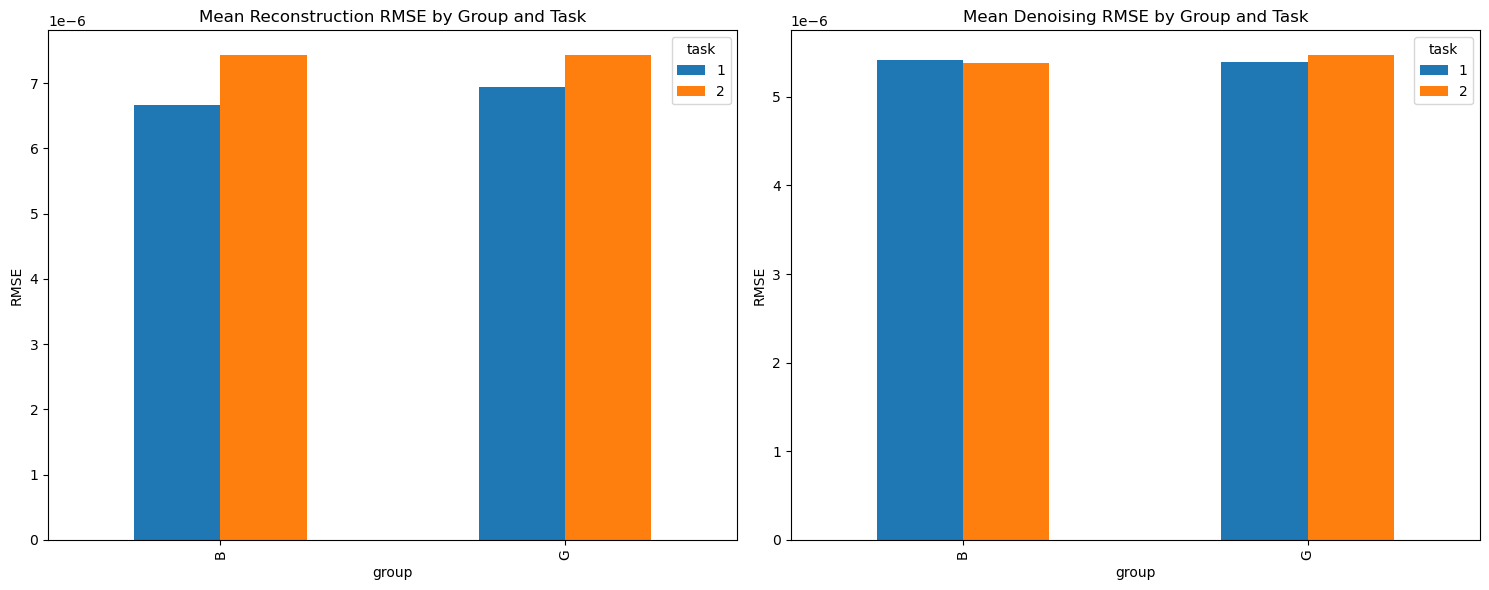

Best reconstruction: Subject Subject18, Task 2, Group G, RMSE 4.073783432976e-06
Best denoising: Subject Subject06, Task 1, Group B, RMSE 5.075136871335e-06


In [25]:
# Comparison and summary
if not results_df.empty:
    # Group by group and task
    summary = results_df.groupby(['group', 'task']).agg({
        'rmse_reconstruction': ['mean', 'std', 'min', 'max'],
        'rmse_denoising': ['mean', 'std', 'min', 'max']
    })

    # Convert to scientific notation (12 decimal) for display and file save
    summary = summary.applymap(lambda x: f"{x:.12e}")
    print("Summary statistics:")
    print(summary)
    
    # Save summary
    summary.to_csv(os.path.join(results_path, "summary_stats.csv"))
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Reconstruction RMSE
    rec_data = results_df.groupby(['group', 'task'])['rmse_reconstruction'].mean().unstack()
    rec_data.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Mean Reconstruction RMSE by Group and Task')
    axes[0].set_ylabel('RMSE')
    
    # Denoising RMSE
    den_data = results_df.groupby(['group', 'task'])['rmse_denoising'].mean().unstack()
    den_data.plot(kind='bar', ax=axes[1])
    axes[1].set_title('Mean Denoising RMSE by Group and Task')
    axes[1].set_ylabel('RMSE')
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_path, "comparison_plot.png"))
    plt.show()
    
    # Best performers
    best_rec = results_df.loc[results_df['rmse_reconstruction'].idxmin()]
    best_den = results_df.loc[results_df['rmse_denoising'].idxmin()]
    print(f"Best reconstruction: Subject {best_rec['subject']}, Task {best_rec['task']}, Group {best_rec['group']}, RMSE {best_rec['rmse_reconstruction']:.12e}")
    print(f"Best denoising: Subject {best_den['subject']}, Task {best_den['task']}, Group {best_den['group']}, RMSE {best_den['rmse_denoising']:.12e}")
else:
    print("No results to summarize.")